In [82]:
# !pip install pandas --upgrade
# !pip install matplotlib --upgrade
# !pip install seaborn --upgrade

In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# show full dataframe output in notebook
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)         # let pandas decide width
pd.set_option('display.max_colwidth', None)  # do not truncate column contents


In [84]:
# # m = pd.read_csv("simulation_results/metrics_20250913_124425.csv")
# # m4 = pd.read_csv("simulation_results/metrics_20251006_164807.csv") #mpeg4 - 4x4 - 500 cycles - 1s interval
# # m4 = pd.read_csv("simulation_results/metrics_20251112_001135.csv")

# # m4 = pd.read_csv("simulation_results/metrics_20251119_003436.csv") # mpeg4 - 4x4 - 100 bandwidth (30 steps até 150%) ok
# # m4 = pd.read_csv("simulation_results/metrics_20251119_004702.csv") # mpeg4 - 4x4 - 100 bandwidth (30 steps até 200%)
# # m4 = pd.read_csv("simulation_results/metrics_20251119_005708.csv") # mpeg4 - 4x4 - 100 bandwidth (50 steps até 150%)
# # m4 = pd.read_csv("simulation_results/metrics_20251119_012315.csv")
# # m8 = pd.read_csv("simulation_results/metrics_20251008_083904.csv") #mpeg4 - 8x8 - 500 cycles - 1s interval
# # m4 = pd.read_csv("simulation_results/metrics_20251121_012544.csv") # mpeg4 - 4x4 - 100 bandwidth (50 steps até 150%) sequencial
# # m4 = pd.read_csv("simulation_results/metrics_20251121_015511.csv") # mpeg4 - 4x4 - 100 bandwidth (100 steps até 130%) sequencial ok
# # m4 = pd.read_csv("simulation_results/metrics_20251121_015858.csv") # mpeg4 - 4x4 - 8 bandwidth (10 steps até 100%) sequencial
# # m4 = pd.read_csv("simulation_results/metrics_20251121_020055.csv") # mpeg4 - 4x4 - 8 bandwidth (30 steps até 50%) sequencial
# # m4 = pd.read_csv("simulation_results/metrics_20251124_020651.csv")
# # m4 = pd.read_csv("simulation_results/metrics_20251126_015735.csv") # teste novo continuous injection
# # m4 = pd.read_csv("simulation_results/metrics_20251127_003910.csv")
# # m4 = pd.read_csv("simulation_results/metrics_20251126_002921.csv")
# # m4 = pd.read_csv("simulation_results/metrics_20251129_001817.csv") # sem perdas - 3 ok
# # m4 = pd.read_csv("simulation_results/metrics_20251205_234141.csv") # sem perdas - 3 retry
# # m4 = pd.read_csv("simulation_results/metrics_20251205_235237.csv") # sem perdas - 2
# # m4 = pd.read_csv("simulation_results/metrics_20251206_000553.csv") # 1
# # m4 = pd.read_csv("simulation_results/metrics_20251207_230513.csv") # 2 + reset on cycle + injection n same EP
# # m4 = pd.read_csv("simulation_results/metrics_20251207_232618.csv") # 5 + injection uniform + buffer 8
# # m4 = pd.read_csv("simulation_results/metrics_20251209_000649.csv") # 5 + injection uniform + buffer 8 + 50 steps
# # m4 = pd.read_csv("simulation_results/metrics_20251209_001842.csv") # 5 + injection uniform + buffer 8 + 50 steps
# # m4 = pd.read_csv("simulation_results//metrics_20251209_005107.csv") # 5 + injection random + buffer 8 + 50 steps
# # m4 = pd.read_csv("simulation_results//metrics_20251209_235053.csv") # 5 + injection uniform + buffer 8 + 50 steps + 80%
# # m4 = pd.read_csv("simulation_results//metrics_20251210_000904.csv") # 5 + injection random + buffer 8 + 50 steps + 100%
# # m4 = pd.read_csv("simulation_results/metrics_20251210_001049.csv") # 5 + injection random + buffer 8 + 50 steps + 100%
# # m4 = pd.read_csv("simulation_results/metrics_20251210_001611.csv") # 5 + injection uniform + buffer 8 + 50 steps + 100%
# m4 = pd.read_csv("simulation_results/metrics_20251210_002223.csv") # 5 + injection uniform + buffer 8 + 100 steps + 150%
# # m4 = pd.read_csv("simulation_results/.csv") # r5 + injection uniform + buffer 4 + 50 steps + 150%

# m8 = pd.read_csv("simulation_results/metrics_20251121_171134.csv")

In [85]:
# root = "metrics_20251210_083334" ok
# root = "metrics_20260118_105242"
root = "20260119_000519"
# root = "metrics_20251211_123613"

STATISTICS_XY = f"simulation_results/{root}/metrics_XY.csv"
STATISTICS_NEGATIVE_FIRST = f"simulation_results/{root}/metrics_NEGATIVE_FIRST.csv"
STATISTICS_NORTH_LEAST = f"simulation_results/{root}/metrics_NORTH_LEAST.csv"
STATISTICS_WEST_FIRST = f"simulation_results/{root}/metrics_WEST_FIRST.csv"

In [86]:
def get_throughput_statistics(df):
    cycles = df[df['type'] == 'packet_arrived'].groupby('execution_id').max()['cycles'].reset_index(name='cycles')
    arrived_flit = df[df['type'] == 'packet_arrived'].groupby('execution_id').count()['packet_id'].reset_index(name='arrived_flits')
    stats = pd.merge(cycles, arrived_flit, on='execution_id')
    stats['throughput'] = stats['arrived_flits'] / stats['cycles']
    return stats

def get_latency_statistics(df):
    df_injected = df[df['type'] == 'packet_sent'].copy()
    # Get the latency mean
    df_arrived = df[df['type'] == 'packet_arrived'].copy()

    df_diff_cycles = pd.merge(
        df_arrived[['packet_id', 'cycles', 'execution_id']],
        df_injected[['packet_id', 'cycles', 'execution_id']],
        on=['packet_id', 'execution_id'],
        suffixes=('_arrived', '_injected')
    )
    df_diff_cycles['cycles'] = df_diff_cycles['cycles_arrived'] - df_diff_cycles['cycles_injected']
    # Get the latency mean
    return df_diff_cycles.groupby(['execution_id']).agg({'cycles': 'mean'}).reset_index().rename(columns={'cycles': 'latency_mean'})

def get_extra_delay_statistics(df):
    
    df_injected = df[df['type'] == 'packet_sent'].copy()
    df_arrived = df[df['type'] == 'packet_arrived'].copy()
    
    df_diff_cycles = pd.merge(
        df_arrived[['packet_id', 'cycles', 'execution_id']],
        df_injected[['packet_id', 'cycles', 'execution_id']],
        on=['packet_id', 'execution_id'],
        suffixes=('_arrived', '_injected')
    )
    # Get the latency for each packet
    df_diff_cycles['cycles'] = df_diff_cycles['cycles_arrived'] - df_diff_cycles['cycles_injected']
    # Get min and mean latency per execution_id
    latency_stats = df_diff_cycles.groupby('execution_id')['cycles'].agg(['min', 'mean']).reset_index()
    latency_stats['extra_delay'] = latency_stats['mean'] - latency_stats['min']
    return latency_stats[['execution_id', 'extra_delay']]

def get_packet_loss_statistics(df):
    
    df_injected = df[df['type'] == 'packet_sent'].copy()
    df_arrived = df[df['type'] == 'packet_arrived'].copy()
    
    df_total_injected = df_injected.groupby('execution_id').size().reset_index(name='total_injected')
    df_total_arrived = df_arrived.groupby('execution_id').size().reset_index(name='total_arrived')

    df_packet_loss = pd.merge(
        df_total_arrived[['execution_id', 'total_arrived']],
        df_total_injected[['execution_id', 'total_injected']],
        on='execution_id'
    )
    df_packet_loss['packet_loss'] = df_packet_loss['total_injected'] - df_packet_loss['total_arrived']
    return df_packet_loss

## Network Throughput

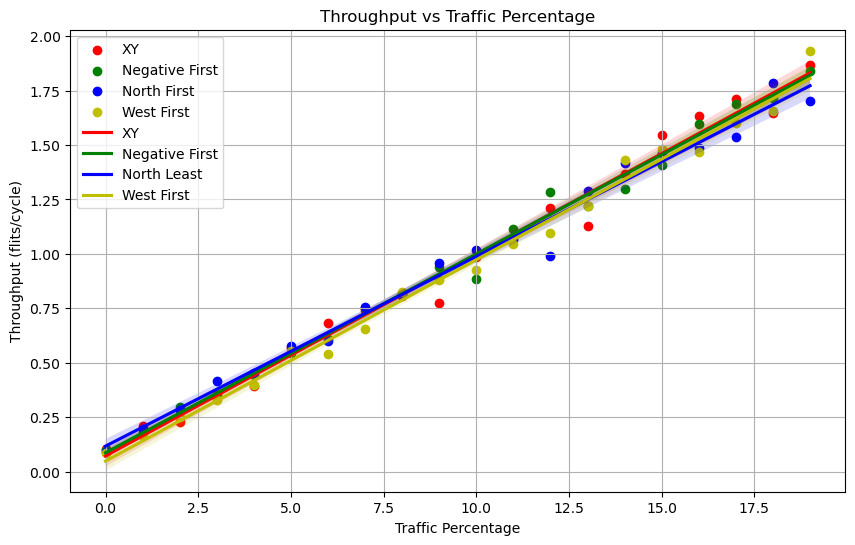

In [87]:
xy_throughput = get_throughput_statistics(pd.read_csv(STATISTICS_XY))
negf_throughput = get_throughput_statistics(pd.read_csv(STATISTICS_NEGATIVE_FIRST))
northl_throughput = get_throughput_statistics(pd.read_csv(STATISTICS_NORTH_LEAST))
westf_throughput = get_throughput_statistics(pd.read_csv(STATISTICS_WEST_FIRST))

plt.figure(figsize=(10, 6))

plt.scatter(xy_throughput.index, xy_throughput['throughput'], marker='o', color='r', label='XY')
plt.scatter(negf_throughput.index, negf_throughput['throughput'], marker='o', color='g', label='Negative First')
plt.scatter(northl_throughput.index, northl_throughput['throughput'], marker='o', color='b', label='North First')
plt.scatter(westf_throughput.index, westf_throughput['throughput'], marker='o', color='y', label='West First')
# Regression line (order 1 = linear)
sns.regplot(x=xy_throughput.index, y=xy_throughput['throughput'], scatter=False, order=1, color='r', label='XY')
sns.regplot(x=negf_throughput.index, y=negf_throughput['throughput'], scatter=False, order=1, color='g', label='Negative First')
sns.regplot(x=northl_throughput.index, y=northl_throughput['throughput'], scatter=False, order=1, color='b', label='North Least')
sns.regplot(x=westf_throughput.index, y=westf_throughput['throughput'], scatter=False, order=1, color='y', label='West First')

plt.title('Throughput vs Traffic Percentage')
plt.xlabel('Traffic Percentage')
plt.ylabel('Throughput (flits/cycle)')
plt.legend()
plt.grid(True)
# plt.yscale('log')  # log scale to see exponential better
plt.show()

## Average Latency

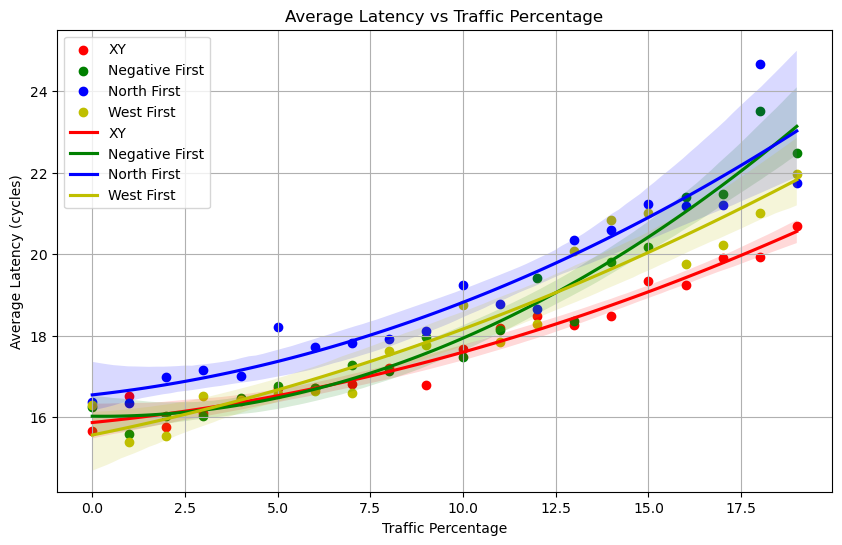

In [88]:
xy_latency = get_latency_statistics(pd.read_csv(STATISTICS_XY))
negf_latency = get_latency_statistics(pd.read_csv(STATISTICS_NEGATIVE_FIRST))
northl_latency = get_latency_statistics(pd.read_csv(STATISTICS_NORTH_LEAST))
westf_latency = get_latency_statistics(pd.read_csv(STATISTICS_WEST_FIRST))

plt.figure(figsize=(10, 6))

plt.scatter(xy_latency.index, xy_latency['latency_mean'], marker='o', color='r', label='XY')
plt.scatter(negf_latency.index, negf_latency['latency_mean'], marker='o', color='g', label='Negative First')
plt.scatter(northl_latency.index, northl_latency['latency_mean'], marker='o', color='b', label='North First')
plt.scatter(westf_latency.index, westf_latency['latency_mean'], marker='o', color='y', label='West First')
# plt.scatter(throughput8.index, throughput8['throughput'], marker='o', label='8x8')
# Regression line (order 1 = linear)
sns.regplot(x=xy_latency.index, y=xy_latency['latency_mean'], scatter=False, order=2, color='r', label='XY')
sns.regplot(x=negf_latency.index, y=negf_latency['latency_mean'], scatter=False, order=2, color='g', label='Negative First')
sns.regplot(x=northl_latency.index, y=northl_latency['latency_mean'], scatter=False, order=2, color='b', label='North First')
sns.regplot(x=westf_latency.index, y=westf_latency['latency_mean'], scatter=False, order=2, color='y', label='West First') 
# sns.regplot(x=throughput8.index, y=throughput8['throughput'], scatter=False, order=3, color='m', label='Regression Line 8x8')

plt.title('Average Latency vs Traffic Percentage')
plt.xlabel('Traffic Percentage')
plt.ylabel('Average Latency (cycles)')
plt.legend()
plt.grid()
# plt.yscale('log')  # log scale to see exponential better
plt.show()

## Extra Delay

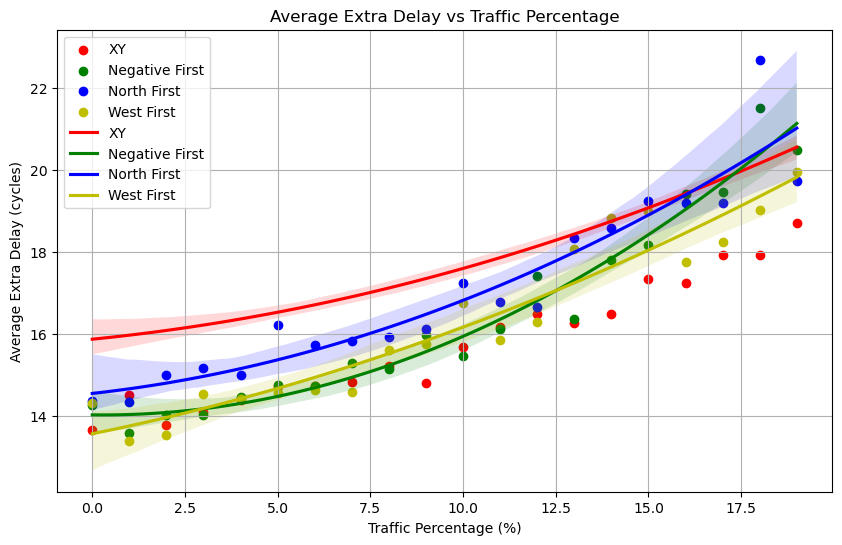

In [89]:
xy_extra_delay = get_extra_delay_statistics(pd.read_csv(STATISTICS_XY))
negf_extra_delay = get_extra_delay_statistics(pd.read_csv(STATISTICS_NEGATIVE_FIRST))
northl_extra_delay = get_extra_delay_statistics(pd.read_csv(STATISTICS_NORTH_LEAST))
westf_extra_delay = get_extra_delay_statistics(pd.read_csv(STATISTICS_WEST_FIRST))

# Plot the extra delay
plt.figure(figsize=(10, 6))

plt.scatter(xy_extra_delay.index, xy_extra_delay['extra_delay'], marker='o', color='r', label='XY')
plt.scatter(negf_extra_delay.index, negf_extra_delay['extra_delay'], marker='o', color='g', label='Negative First')
plt.scatter(northl_extra_delay.index, northl_extra_delay['extra_delay'], marker='o', color='b', label='North First')
plt.scatter(westf_extra_delay.index, westf_extra_delay['extra_delay'], marker='o', color='y', label='West First')

# Regression line (order 1 = linear)
sns.regplot(x=xy_latency.index, y=xy_latency['latency_mean'], scatter=False, order=2, color='r', label='XY')
sns.regplot(x=negf_extra_delay.index, y=negf_extra_delay['extra_delay'], scatter=False, order=2, color='g', label='Negative First')
sns.regplot(x=northl_extra_delay.index, y=northl_extra_delay['extra_delay'], scatter=False, order=2, color='b', label='North First')
sns.regplot(x=westf_extra_delay.index, y=westf_extra_delay['extra_delay'], scatter=False, order=2, color='y', label='West First') 

plt.title('Average Extra Delay vs Traffic Percentage')
plt.xlabel('Traffic Percentage (%)')
plt.ylabel('Average Extra Delay (cycles)')
plt.grid(True)
plt.legend()    
plt.show()

## Packet Loss

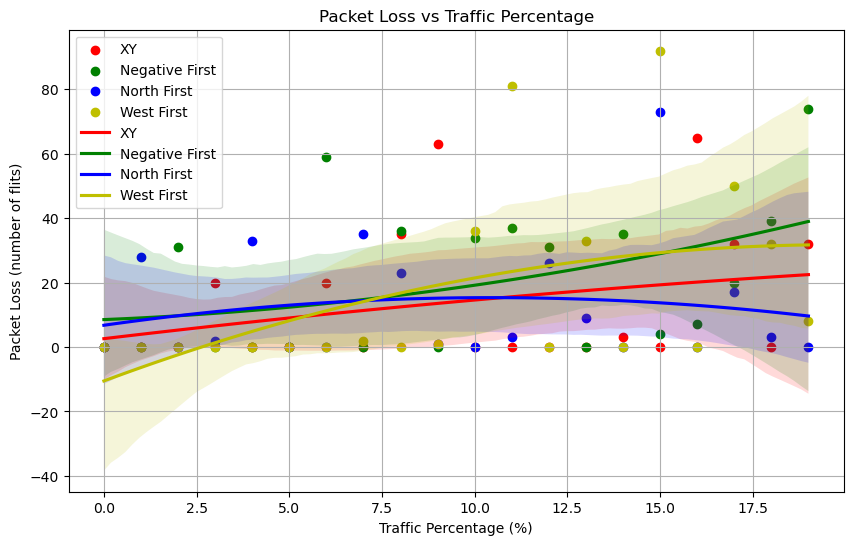

In [90]:
xy_packet_loss = get_packet_loss_statistics(pd.read_csv(STATISTICS_XY))
negf_packet_loss = get_packet_loss_statistics(pd.read_csv(STATISTICS_NEGATIVE_FIRST))
northl_packet_loss = get_packet_loss_statistics(pd.read_csv(STATISTICS_NORTH_LEAST))
westf_packet_loss = get_packet_loss_statistics(pd.read_csv(STATISTICS_WEST_FIRST))

# Plot the packet loss
plt.figure(figsize=(10, 6))

plt.scatter(xy_packet_loss.index, xy_packet_loss['packet_loss'], marker='o', color='r', label='XY')
plt.scatter(negf_packet_loss.index, negf_packet_loss['packet_loss'], marker='o', color='g', label='Negative First')
plt.scatter(northl_packet_loss.index, northl_packet_loss['packet_loss'], marker='o', color='b', label='North First')
plt.scatter(westf_packet_loss.index, westf_packet_loss['packet_loss'], marker='o', color='y', label='West First')

# Regression line (order 1 = linear)
sns.regplot(x=xy_packet_loss.index, y=xy_packet_loss['packet_loss'], scatter=False, order=2, color='r', label='XY')
sns.regplot(x=negf_packet_loss.index, y=negf_packet_loss['packet_loss'], scatter=False, order=2, color='g', label='Negative First')
sns.regplot(x=northl_packet_loss.index, y=northl_packet_loss['packet_loss'], scatter=False, order=2, color='b', label='North First')
sns.regplot(x=westf_packet_loss.index, y=westf_packet_loss['packet_loss'], scatter=False, order=2, color='y', label='West First') 

plt.title('Packet Loss vs Traffic Percentage')
plt.xlabel('Traffic Percentage (%)')
plt.ylabel('Packet Loss (number of flits)')
plt.grid(True)
plt.legend()    
plt.show()

In [91]:
sorteddf_diff_cycles = df_diff_cycles.sort_values(['execution_id', 'packet_id'])

plt.figure(figsize=(10, 6))

plt.scatter(sorteddf_diff_cycles.index, sorteddf_diff_cycles['cycles'], marker='o', label='4x4')
plt.title('Latency vs Traffic Percentage')
plt.xlabel('Traffic Percentage')
plt.ylabel('Latency (cycles)')
plt.legend()
plt.grid()
# plt.yscale('log')  # log scale to see exponential better
plt.show()

NameError: name 'df_diff_cycles' is not defined

,execution_id,mean_latency,std_latency,max_latency
0,1.0,13.666667,8.565712,34
1,2.0,17.652778,9.591898,44
2,3.0,21.296296,10.998946,44
3,4.0,28.909722,16.402675,69
4,5.0,27.756944,14.468798,69
5,6.0,32.161111,17.497698,82
6,7.0,35.592593,19.479524,84
7,8.0,40.361111,21.739140,89
8,9.0,43.152778,23.386860,104
9,10.0,42.170139,21.025674,104


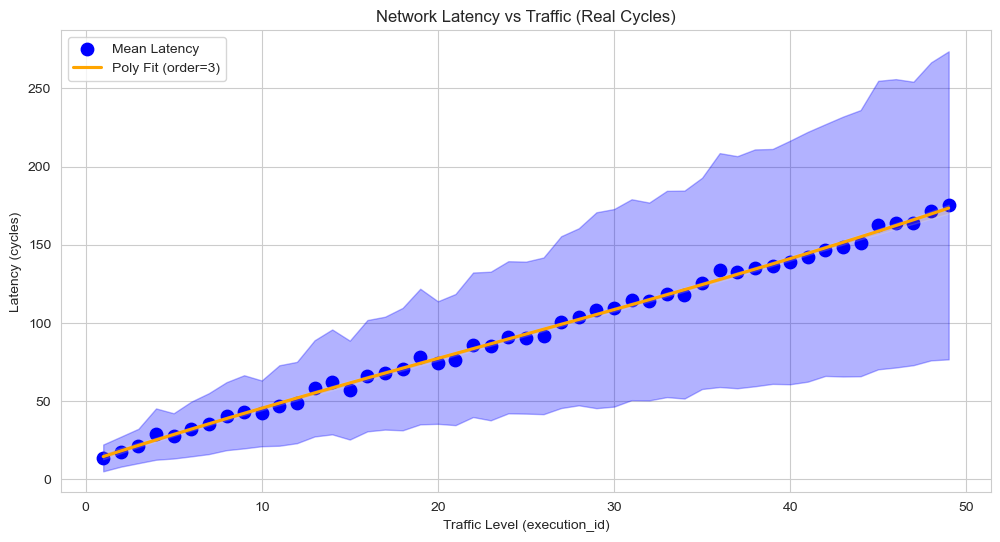

In [ ]:
# Real latency = arrival cycle - injection cycle (requires 'cycle' in metrics)
df_sent = m4[m4['type'] == 'packet_sent'][['execution_id', 'packet_id', 'cycles']].rename(columns={'cycles': 'sent_cycle'})
df_arrived = m4[m4['type'] == 'packet_arrived'][['execution_id', 'packet_id', 'cycles']].rename(columns={'cycles': 'arrived_cycle'})

latency_real = pd.merge(df_sent, df_arrived, on=['execution_id', 'packet_id'], how='inner')
latency_real['latency_cycles'] = latency_real['arrived_cycle'] - latency_real['sent_cycle']

# per-execution summary
latency_summary = latency_real.groupby('execution_id').agg(
    mean_latency=('latency_cycles', 'mean'),
    std_latency=('latency_cycles', 'std'),
    max_latency=('latency_cycles', 'max')
).reset_index()

display(latency_summary)

# Plot: should show exponential growth as congestion builds
plt.figure(figsize=(12, 6))
plt.scatter(latency_summary['execution_id'], latency_summary['mean_latency'], marker='o', s=80, label='Mean Latency', color='b')
plt.fill_between(latency_summary['execution_id'], 
                  latency_summary['mean_latency'] - latency_summary['std_latency'],
                  latency_summary['mean_latency'] + latency_summary['std_latency'],
                  alpha=0.3, color='b')

sns.regplot(x=latency_summary['execution_id'], y=latency_summary['mean_latency'], 
            scatter=False, order=3, color='orange', label='Poly Fit (order=3)')

plt.title('Network Latency vs Traffic (Real Cycles)')
plt.xlabel('Traffic Level (execution_id)')
plt.ylabel('Latency (cycles)')
plt.legend()
plt.grid(True)
# plt.yscale('log')  # log scale to see exponential better
plt.show()

In [ ]:
# Get the total packets lost per traffic level
injected_flits = m4[m4['type'] == 'packet_sent'].groupby('execution_id').sum()['weight'].reset_index(name='injected_flits')
lost_flits = m4[m4['type'] == 'packet_loss'].groupby('execution_id').sum()['weight'].reset_index(name='lost_flits')
# total_lost8 = loss8.groupby('execution_id').size().reset_index(name='total_lost')
# Merge the two dataframes
loss_stats4 = pd.merge(injected_flits, lost_flits, on='execution_id', how='left').fillna(0)
# loss_stats8 = pd.merge(total_sent8, total_lost8, on='execution_id', how='left').fillna(0)
# Calculate loss rate
loss_stats4['loss_rate'] = loss_stats4['lost_flits'] / loss_stats4['injected_flits']
# loss_stats8['loss_rate'] = loss_stats8['total_lost'] / loss_stats8['total_sent'] 

plt.figure(figsize=(10, 6))

# Plot only points for both grids
plt.scatter(loss_stats4['execution_id'], loss_stats4['loss_rate'], color='b', label='4x4 Grid')
# plt.scatter(loss_stats8['execution_id'], loss_stats8['loss_rate'], color='g', label='8x8 Grid')

# Regression lines for both grids
sns.regplot(x=loss_stats4['execution_id'], y=loss_stats4['loss_rate'], scatter=False, order=2, color='b', label='4x4 Regression')
# sns.regplot(x=loss_stats8['execution_id'], y=loss_stats8['loss_rate'], scatter=False, order=3, color='g', label='8x8 Regression')

plt.title('Packet Loss Rate vs Traffic Percentage')
plt.xlabel('Traffic Percentage (%)')
plt.ylabel('Packet Loss Rate')
plt.grid(True)
plt.legend()
plt.show()

NameError: name 'm4' is not defined